In [28]:
import pandas as pd
import statsmodels.api as sm
import itertools
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV
# from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score




In [2]:
df = pd.read_csv('data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Select only set features at random (or choose specific ones if you prefer)

# Assuming your dataset is in a variable called 'df'
# 'y' is the target column, 'X' contains the predictors
target = 'diagnosis'
y = df[target].map({'M': 1, 'B': 0})  # Convert to numeric
X = df.drop(columns=[target])

np.random.seed(42)  # For reproducibility
selected_features = np.random.choice(X.columns, 11, replace=False)
X_reduced = X[selected_features]

def fit_linear_reg_reduced(feature_set):
    X_subset = sm.add_constant(X_reduced[list(feature_set)])
    model = sm.OLS(y, X_subset).fit()
    return {"model": model, "RSS": model.ssr, "R2": model.rsquared, 
            "Adj_R2": model.rsquared_adj, "BIC": model.bic, "AIC": model.aic}

best_models_per_k_reduced = []

for k in range(1, len(X_reduced.columns) + 1):
    best_rss = float("inf")
    best_subset_for_k = None
    
    for combo in itertools.combinations(X_reduced.columns, k):
        results = fit_linear_reg_reduced(combo)
        if results["RSS"] < best_rss:
            best_rss = results["RSS"]
            best_subset_for_k = results
            
    best_models_per_k_reduced.append(best_subset_for_k)

models_df_reduced = pd.DataFrame(best_models_per_k_reduced)

best_overall_model_reduced = models_df_reduced.loc[models_df_reduced['BIC'].idxmin()]
print(f"Best subset features (reduced): {best_overall_model_reduced['model'].model.exog_names}")

Best subset features (reduced): ['const', 'concavity_worst', 'smoothness_se', 'perimeter_worst', 'concavity_se', 'symmetry_worst', 'area_worst', 'texture_se']


In [4]:
# # Assuming your dataset is in a variable called 'df'
# # 'y' is the target column, 'X' contains the predictors
# target = 'diagnosis'
# y = df[target].map({'M': 1, 'B': 0})  # Convert to numeric
# X = df.drop(columns=[target])

# def fit_linear_reg(feature_set):
#     # Standard least squares regression as mentioned in the sources [1, 4]
#     X_subset = sm.add_constant(X[list(feature_set)])
#     model = sm.OLS(y, X_subset).fit()
#     return {"model": model, "RSS": model.ssr, "R2": model.rsquared, 
#             "Adj_R2": model.rsquared_adj, "BIC": model.bic, "AIC": model.aic}

# # List to store the best model for each number of predictors k
# best_models_per_k = []

# # Iterating through k = 1 to p as per Algorithm 6.1 [1]
# for k in range(1, len(X.columns) + 1):
#     best_rss = float("inf")
#     best_subset_for_k = None
    
#     # Check all combinations of size k
#     for combo in itertools.combinations(X.columns, k):
#         results = fit_linear_reg(combo)
#         if results["RSS"] < best_rss:
#             best_rss = results["RSS"]
#             best_subset_for_k = results
            
#     best_models_per_k.append(best_subset_for_k)

# # Convert to DataFrame for easy comparison
# models_df = pd.DataFrame(best_models_per_k)

# # Final Selection: Picking the model with the lowest BIC as suggested [1]
# best_overall_model = models_df.loc[models_df['BIC'].idxmin()]
# print(f"Best subset features: {best_overall_model['model'].model.exog_names}")


In [5]:
def forward_stepwise_selection(X, y):
    # Algorithm 6.2: Start with the null model M0 (no predictors) [1]
    features = []
    models_sequence = []
    remaining_features = list(X.columns)

    for k in range(len(X.columns)):
        best_rss = float('inf')
        best_feature = None
        best_model = None

        # Consider all models that augment the current predictors with one additional predictor [1]
        for combo in remaining_features:
            X_subset = sm.add_constant(X[features + [combo]])
            model = sm.OLS(y, X_subset).fit()
            
            # Identify the best split by minimizing the Residual Sum of Squares (RSS) [1, 3]
            if model.ssr < best_rss:
                best_rss = model.ssr
                best_feature = combo
                best_model = model

        features.append(best_feature)
        remaining_features.remove(best_feature)
        models_sequence.append({'k': len(features), 'model': best_model, 'features': list(features)})

    return pd.DataFrame(models_sequence)

# Execute Forward Selection
fwd_results = forward_stepwise_selection(X, y)

# Interpretation: Extract metrics to select the best overall model [1]
fwd_metrics = pd.DataFrame({
    'Num_Predictors': fwd_results['k'],
    'BIC': [m.bic for m in fwd_results['model']],
    'Adj_R2': [m.rsquared_adj for m in fwd_results['model']]
})

print("Forward Stepwise Selection Results:")
print(fwd_metrics.sort_values(by='BIC', ascending=True))

# GUIDANCE: To choose the 'best' model from this sequence, look for the minimum BIC 
# or maximum Adjusted R2. BIC is often preferred as it penalizes model complexity more heavily [1].

Forward Stepwise Selection Results:
    Num_Predictors         BIC    Adj_R2
10              11   42.003531  0.759456
12              13   43.702551  0.763207
11              12   44.024996  0.760847
13              14   45.691860  0.764588
9               10   46.658804  0.755200
8                9   48.526198  0.752086
14              15   49.962536  0.765020
7                8   51.951025  0.748244
15              16   53.879263  0.765596
6                7   57.220036  0.743511
5                6   58.332647  0.740590
16              17   58.534684  0.765867
17              18   64.253494  0.765698
4                5   69.381249  0.733013
18              19   70.147001  0.765457
19              20   76.097972  0.765191
20              21   82.038432  0.764929
21              22   87.973887  0.764667
3                4   89.648772  0.720726
22              23   93.691645  0.764495
23              24   99.560325  0.764259
2                3  102.031432  0.711893
24              25  1

In [6]:
def backward_stepwise_selection(X, y):
    # Algorithm 6.3: Start with the full model Mp containing all p predictors [2]
    features = list(X.columns)
    models_sequence = []

    while len(features) > 0:
        X_subset = sm.add_constant(X[features])
        current_model = sm.OLS(y, X_subset).fit()
        models_sequence.append({'k': len(features), 'model': current_model, 'features': list(features)})
        
        if len(features) == 1:
            break

        best_rss = float('inf')
        feature_to_remove = None

        # Iteratively remove the least useful predictor to find the best model with k-1 variables [2]
        for feature in features:
            subset = [f for f in features if f != feature]
            X_temp = sm.add_constant(X[subset])
            model = sm.OLS(y, X_temp).fit()
            
            # Best is defined as the subset with the smallest RSS [2, 3]
            if model.ssr < best_rss:
                best_rss = model.ssr
                feature_to_remove = feature

        features.remove(feature_to_remove)

    return pd.DataFrame(models_sequence)

# Execute Backward Selection
bwd_results = backward_stepwise_selection(X, y)

# Interpretation: Evaluate the sequence of models [2]
bwd_metrics = pd.DataFrame({
    'Num_Predictors': bwd_results['k'],
    'BIC': [m.bic for m in bwd_results['model']],
    'AIC': [m.aic for m in bwd_results['model']]
})

print("\nBackward Stepwise Selection Results:")
print(fwd_metrics.sort_values(by='BIC', ascending=True))

# GUIDANCE: Compare the BIC across models. The goal is to reduce the test MSE 
# by finding a subset of variables that achieves a low bias-variance trade-off [3, 5].


Backward Stepwise Selection Results:
    Num_Predictors         BIC    Adj_R2
10              11   42.003531  0.759456
12              13   43.702551  0.763207
11              12   44.024996  0.760847
13              14   45.691860  0.764588
9               10   46.658804  0.755200
8                9   48.526198  0.752086
14              15   49.962536  0.765020
7                8   51.951025  0.748244
15              16   53.879263  0.765596
6                7   57.220036  0.743511
5                6   58.332647  0.740590
16              17   58.534684  0.765867
17              18   64.253494  0.765698
4                5   69.381249  0.733013
18              19   70.147001  0.765457
19              20   76.097972  0.765191
20              21   82.038432  0.764929
21              22   87.973887  0.764667
3                4   89.648772  0.720726
22              23   93.691645  0.764495
23              24   99.560325  0.764259
2                3  102.031432  0.711893
24              25 

In [7]:


# 1. Preprocessing: Standardizing predictors is crucial for Ridge
# This ensures the penalty is applied fairly across all variables [1]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Define a range of lambda (alpha in sklearn) values
lambdas = 10**np.linspace(6, -2, 100)

# 3. RidgeCV: Automatically find the best lambda using cross-validation [2]
ridge_cv = RidgeCV(alphas=lambdas, scoring='neg_mean_squared_error', cv=10)
ridge_cv.fit(X_scaled, y)
best_lambda = ridge_cv.alpha_

print(f"Optimal Lambda (λ): {best_lambda}")

# 4. Fit the final model with the best lambda
final_model = Ridge(alpha=best_lambda)
final_model.fit(X_scaled, y)

Optimal Lambda (λ): 2.205130739903041


Ridge(alpha=np.float64(2.205130739903041))

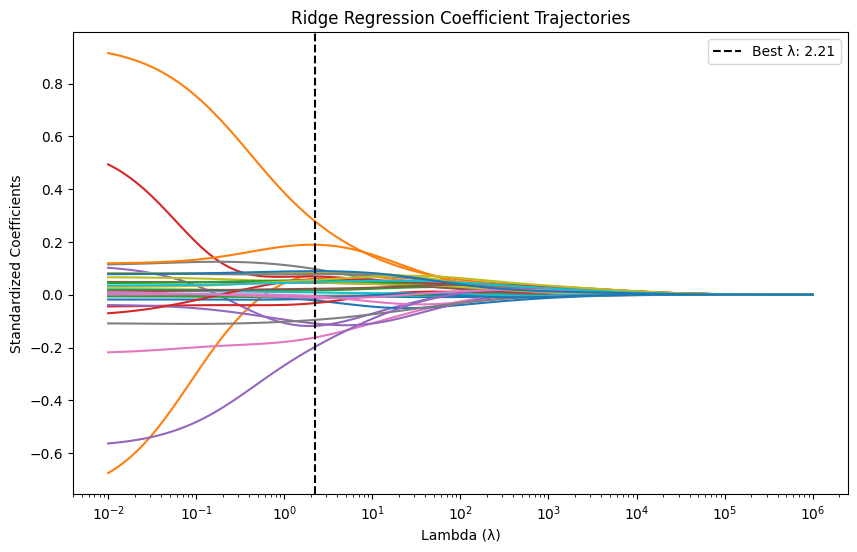

In [8]:
coefs = []
for l in lambdas:
    ridge = Ridge(alpha=l)
    ridge.fit(X_scaled, y)
    coefs.append(ridge.coef_)

# Plotting
plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.plot(lambdas, coefs)
ax.set_xscale('log') # Lambda is typically viewed on a log scale
plt.xlabel('Lambda (λ)')
plt.ylabel('Standardized Coefficients')
plt.title('Ridge Regression Coefficient Trajectories')
plt.axvline(x=best_lambda, color='black', linestyle='--', label=f'Best λ: {best_lambda:.2f}')
plt.legend()
plt.show()

In [9]:
# 1. Preprocessing: Standardize predictors
# Lasso is scale-sensitive; standardization ensures the penalty is applied uniformly [3]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Define a range of lambda (alpha in sklearn) values
lambdas = 10**np.linspace(6, -2, 100)

# 3. LassoCV: Find the best lambda using k-fold cross-validation [2]
# The sources recommend cross-validation as lambda is not a model parameter [2]
lasso_cv = LassoCV(alphas=lambdas, cv=10, max_iter=10000)
lasso_cv.fit(X_scaled, y)
best_lambda = lasso_cv.alpha_

print(f"Optimal Lambda (λ): {best_lambda}")

# 4. Fit the final sparse model
final_lasso = Lasso(alpha=best_lambda)
final_lasso.fit(X_scaled, y)

# Identify selected variables (coefficients != 0)
selected_features = X.columns[final_lasso.coef_ != 0]
print(f"Variables selected by Lasso: {list(selected_features)}")

Optimal Lambda (λ): 0.017475284000076828
Variables selected by Lasso: ['texture_mean', 'concave points_mean', 'radius_se', 'radius_worst', 'texture_worst', 'smoothness_worst', 'concave points_worst', 'symmetry_worst']


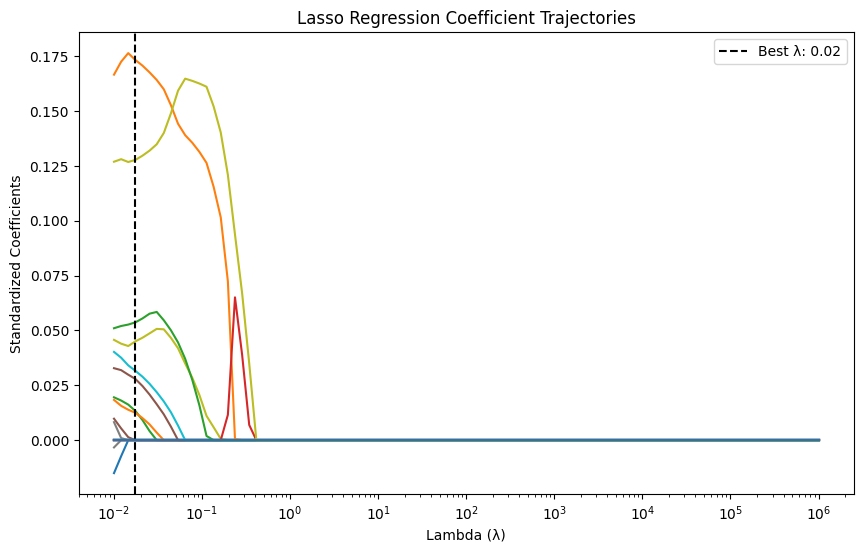

In [10]:
coefs = []
for l in lambdas:
    lasso = Lasso(alpha=l, max_iter=10000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.plot(lambdas, coefs)
ax.set_xscale('log')
plt.xlabel('Lambda (λ)')
plt.ylabel('Standardized Coefficients')
plt.title('Lasso Regression Coefficient Trajectories')
plt.axvline(x=best_lambda, color='black', linestyle='--', label=f'Best λ: {best_lambda:.2f}')
plt.legend()
plt.show()

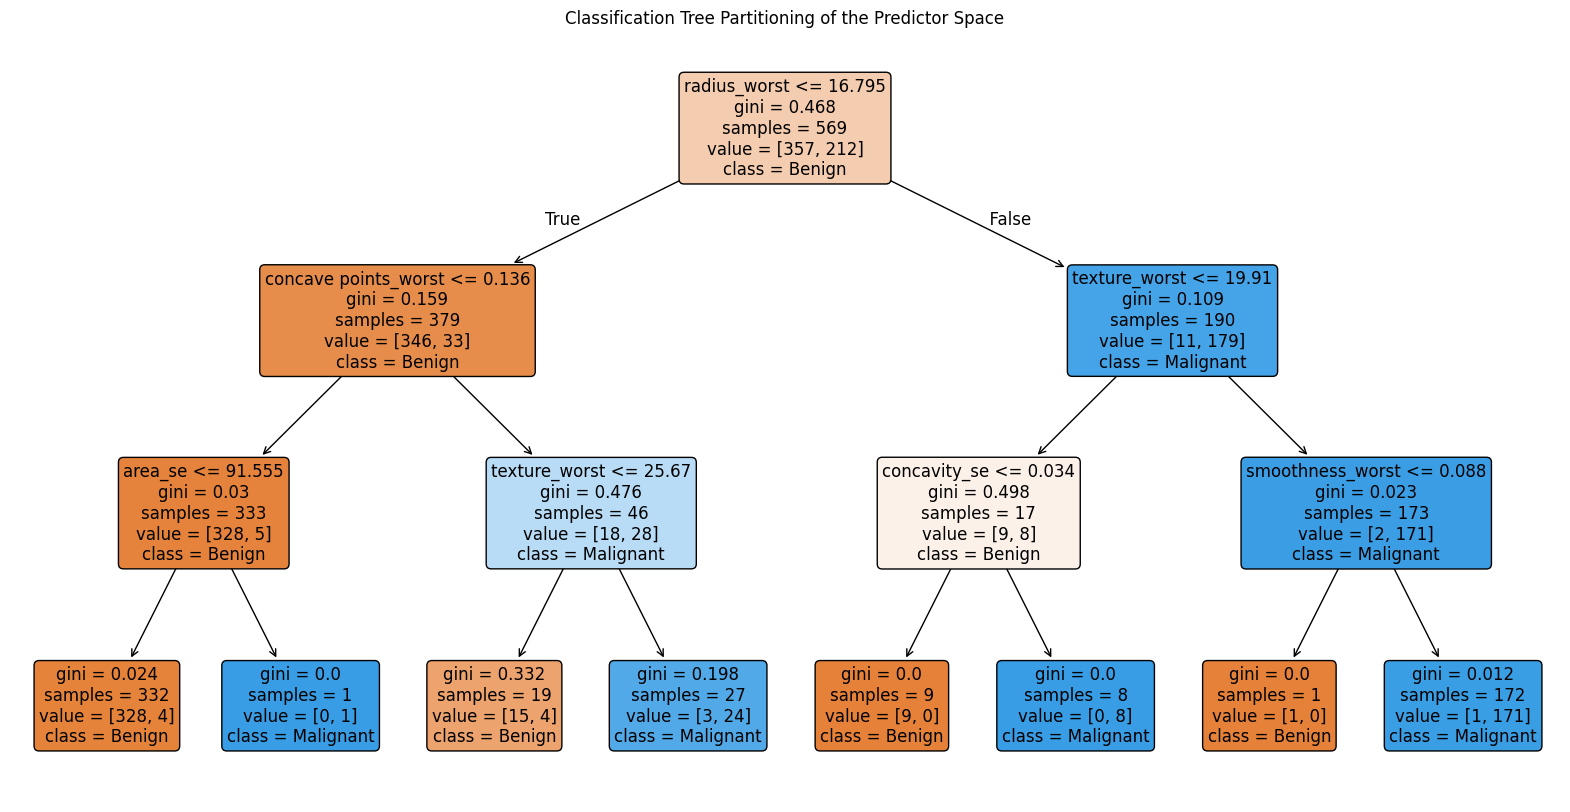

In [14]:
# 1. Initialize the classifier tree

clf_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. Fit the model to your data
clf_tree.fit(X, y)

# 3. Visualization of the Result Tree
plt.figure(figsize=(20, 10))
plot_tree(clf_tree, 
          feature_names=X.columns, 
          class_names=['Benign', 'Malignant'],
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("Classification Tree Partitioning of the Predictor Space")
plt.show()

In [16]:

# Predict on the training data
y_pred = clf_tree.predict(X)

# Calculate metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
cm = confusion_matrix(y, y_pred)
report = classification_report(y, y_pred, target_names=['Benign', 'Malignant'])

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)

Accuracy:  0.979
Precision: 0.981
Recall:    0.962

Confusion Matrix:
[[353   4]
 [  8 204]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.99      0.98       357
   Malignant       0.98      0.96      0.97       212

    accuracy                           0.98       569
   macro avg       0.98      0.98      0.98       569
weighted avg       0.98      0.98      0.98       569



In [23]:
# 1. Initialize the Bagging Classifier with Decision Trees as base estimators
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

# 2. Cross-validation (e.g., 5-fold)
cv_scores = cross_val_score(bagging, X, y, cv=5, scoring='accuracy')
print(f"Cross-validated Accuracy (mean ± std): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# 3. Fit the model on the whole data
bagging.fit(X, y)

# 4. Predict on the training data
y_pred_bag = bagging.predict(X)

# 5. Calculate metrics
accuracy_bag = accuracy_score(y, y_pred_bag)
precision_bag = precision_score(y, y_pred_bag)
recall_bag = recall_score(y, y_pred_bag)
cm_bag = confusion_matrix(y, y_pred_bag)
report_bag = classification_report(y, y_pred_bag, target_names=['Benign', 'Malignant'])

print(f"\nBagging Classifier Results (on training data):")
print(f"Accuracy:  {accuracy_bag:.3f}")
print(f"Precision: {precision_bag:.3f}")
print(f"Recall:    {recall_bag:.3f}")
print("\nConfusion Matrix:")
print(cm_bag)
print("\nClassification Report:")
print(report_bag)

# Interpretation:
print(
    "\nInterpretation:\n"
    "Cross-validation provides a better estimate of the model's generalization performance and helps avoid overfitting. "
    "Compare the cross-validated accuracy with the training accuracy: if training accuracy is much higher, overfitting may be present. "
    "Bagging reduces variance and typically improves stability and accuracy compared to a single tree."
)

Cross-validated Accuracy (mean ± std): 0.956 ± 0.030

Bagging Classifier Results (on training data):
Accuracy:  1.000
Precision: 1.000
Recall:    1.000

Confusion Matrix:
[[357   0]
 [  0 212]]

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       357
   Malignant       1.00      1.00      1.00       212

    accuracy                           1.00       569
   macro avg       1.00      1.00      1.00       569
weighted avg       1.00      1.00      1.00       569


Interpretation:
Cross-validation provides a better estimate of the model's generalization performance and helps avoid overfitting. Compare the cross-validated accuracy with the training accuracy: if training accuracy is much higher, overfitting may be present. Bagging reduces variance and typically improves stability and accuracy compared to a single tree.


In [26]:
# 1. Initialize the Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    random_state=42
)

# 2. Cross-validation (e.g., 5-fold)
cv_scores_rf = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print(f"Random Forest Cross-validated Accuracy (mean ± std): {cv_scores_rf.mean():.3f} ± {cv_scores_rf.std():.3f}")

# 3. Fit the model on the whole data
rf.fit(X, y)

# 4. Predict on the training data
y_pred_rf = rf.predict(X)

# 5. Calculate metrics
accuracy_rf = accuracy_score(y, y_pred_rf)
precision_rf = precision_score(y, y_pred_rf)
recall_rf = recall_score(y, y_pred_rf)
cm_rf = confusion_matrix(y, y_pred_rf)
report_rf = classification_report(y, y_pred_rf, target_names=['Benign', 'Malignant'])

print(f"\nRandom Forest Results (on training data):")
print(f"Accuracy:  {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall:    {recall_rf:.3f}")
print("\nConfusion Matrix:")
print(cm_rf)
print("\nClassification Report:")
print(report_rf)

# Interpretation:
print(
    "\nInterpretation:\n"
    "Random Forests further reduce variance compared to bagging by also randomly selecting features for each split, "
    "which decorrelates the trees and often improves generalization. "
    "Compare the cross-validated accuracy and training accuracy to assess overfitting. "
    "Random Forests typically outperform single trees and bagging, especially when the number of predictors is large."
)

Random Forest Cross-validated Accuracy (mean ± std): 0.958 ± 0.020

Random Forest Results (on training data):
Accuracy:  1.000
Precision: 1.000
Recall:    1.000

Confusion Matrix:
[[357   0]
 [  0 212]]

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       357
   Malignant       1.00      1.00      1.00       212

    accuracy                           1.00       569
   macro avg       1.00      1.00      1.00       569
weighted avg       1.00      1.00      1.00       569


Interpretation:
Random Forests further reduce variance compared to bagging by also randomly selecting features for each split, which decorrelates the trees and often improves generalization. Compare the cross-validated accuracy and training accuracy to assess overfitting. Random Forests typically outperform single trees and bagging, especially when the number of predictors is large.


In [29]:
# 1. Initialize the Gradient Boosting Classifier
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# 2. Cross-validation (e.g., 5-fold)
cv_scores_gb = cross_val_score(gb, X, y, cv=5, scoring='accuracy')
print(f"Gradient Boosting Cross-validated Accuracy (mean ± std): {cv_scores_gb.mean():.3f} ± {cv_scores_gb.std():.3f}")

# 3. Fit the model on the whole data
gb.fit(X, y)

# 4. Predict on the training data
y_pred_gb = gb.predict(X)

# 5. Calculate metrics
accuracy_gb = accuracy_score(y, y_pred_gb)
precision_gb = precision_score(y, y_pred_gb)
recall_gb = recall_score(y, y_pred_gb)
cm_gb = confusion_matrix(y, y_pred_gb)
report_gb = classification_report(y, y_pred_gb, target_names=['Benign', 'Malignant'])

print(f"\nGradient Boosting Results (on training data):")
print(f"Accuracy:  {accuracy_gb:.3f}")
print(f"Precision: {precision_gb:.3f}")
print(f"Recall:    {recall_gb:.3f}")
print("\nConfusion Matrix:")
print(cm_gb)
print("\nClassification Report:")
print(report_gb)

# Interpretation:
print(
    "\nInterpretation:\n"
    "Boosting builds an ensemble of weak learners (shallow trees), where each new tree focuses on correcting the errors of the previous ones. "
    "It often achieves higher accuracy than bagging and random forests, but can be more sensitive to overfitting if not tuned properly. "
    "Compare the cross-validated accuracy and training accuracy to assess generalization. "
    "If training accuracy is much higher than cross-validated accuracy, the model may be overfitting."
)

Gradient Boosting Cross-validated Accuracy (mean ± std): 0.954 ± 0.020

Gradient Boosting Results (on training data):
Accuracy:  1.000
Precision: 1.000
Recall:    1.000

Confusion Matrix:
[[357   0]
 [  0 212]]

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       357
   Malignant       1.00      1.00      1.00       212

    accuracy                           1.00       569
   macro avg       1.00      1.00      1.00       569
weighted avg       1.00      1.00      1.00       569


Interpretation:
Boosting builds an ensemble of weak learners (shallow trees), where each new tree focuses on correcting the errors of the previous ones. It often achieves higher accuracy than bagging and random forests, but can be more sensitive to overfitting if not tuned properly. Compare the cross-validated accuracy and training accuracy to assess generalization. If training accuracy is much higher than cross-validated accuracy, t